## Amazon Sales Analysis: How Discounts Affect Sales, Revenue, and Profit


In [1]:


from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.base import clone
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
np.random.seed(42)
pd.options.display.float_format = '{:,.2f}'.format
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12


## Load Data and Create Helper Features


In [2]:
possible_paths = [
    Path('C:/Users/MOUSUMI/AppData/Local/Temp/cleaned_dataset.csv'),
    Path('cleaned_dataset.csv'),
    Path('data/cleaned_dataset.csv')
]

data_path = next((path for path in possible_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('Dataset not found. Update `possible_paths` with the correct CSV path.')

df = pd.read_csv(data_path, parse_dates=['order_date'])

# Time-based helper feature for monthly aggregation.
df['month'] = df['order_date'].dt.to_period('M').dt.to_timestamp()

# Binary label to compare discounted vs non-discounted transactions.
df['discount_flag'] = np.where(df['discount_percent'] > 0, 'Discounted', 'No Discount')

print(f'Using dataset: {data_path}')
df.head()


Using dataset: cleaned_dataset.csv


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,profit,month,discount_flag
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.50,443,115.88,463.52,23.18,2022-04-01,Discounted
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.70,475,242.08,"1,210.40",60.52,2023-03-01,Discounted
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.40,183,396.64,793.28,39.66,2022-09-01,Discounted
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.00,212,316.16,"1,264.64",63.23,2022-04-01,Discounted
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.60,308,201.68,806.72,40.34,2022-03-01,No Discount


## Dataset Overview and Data Quality Checks


In [3]:
print('Shape:', df.shape)
print('Date range:', df['order_date'].min().date(), 'to', df['order_date'].max().date())
print('Categories:', sorted(df['product_category'].unique()))
print('Regions:', sorted(df['customer_region'].unique()))
print('Discount levels:', sorted(df['discount_percent'].unique()))
print('Unique products:', df['product_id'].nunique())

display(df.isna().sum().rename('missing_values').to_frame())

summary_stats = df.describe(include='all').transpose()
display(summary_stats)

derived_check = pd.DataFrame({
    'max_revenue_formula_error': [(df['total_revenue'] - df['discounted_price'] * df['quantity_sold']).abs().max()],
    'profit_ratio_min': [(df['profit'] / df['total_revenue']).min()],
    'profit_ratio_max': [(df['profit'] / df['total_revenue']).max()]
})
display(derived_check)


Shape: (50000, 16)
Date range: 2022-01-01 to 2023-12-31
Categories: ['Beauty', 'Books', 'Electronics', 'Fashion', 'Home & Kitchen', 'Sports']
Regions: ['Asia', 'Europe', 'Middle East', 'North America']
Discount levels: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20), np.int64(30)]
Unique products: 4000


,missing_values
order_id,0
order_date,0
product_id,0
product_category,0
price,0
discount_percent,0
quantity_sold,0
customer_region,0
payment_method,0
rating,0


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,"50,000.00",NaN,NaN,NaN,"25,000.50",1.00,"12,500.75","25,000.50","37,500.25","50,000.00","14,433.90"
order_date,50000,NaN,NaN,NaN,2022-12-31 10:47:16.800000256,2022-01-01 00:00:00,2022-07-02 00:00:00,2023-01-02 00:00:00,2023-07-02 00:00:00,2023-12-31 00:00:00,NaN
product_id,"50,000.00",NaN,NaN,NaN,"2,986.85","1,000.00","1,983.00","2,983.00","3,989.00","4,999.00","1,156.37"
product_category,50000,6,Beauty,8465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,"50,000.00",NaN,NaN,NaN,252.51,5.01,127.84,252.97,376.33,499.99,143.03
discount_percent,"50,000.00",NaN,NaN,NaN,13.34,0.00,5.00,10.00,20.00,30.00,9.85
quantity_sold,"50,000.00",NaN,NaN,NaN,3.00,1.00,2.00,3.00,4.00,5.00,1.42
customer_region,50000,4,Asia,12526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,50000,5,Wallet,10106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,"50,000.00",NaN,NaN,NaN,3.00,1.00,2.00,3.00,4.00,5.00,1.15


,max_revenue_formula_error,profit_ratio_min,profit_ratio_max
0,0.00,0.05,0.05


# Task 1: Exploratory Data Analysis


,discount_percent,orders,avg_quantity_sold,median_quantity_sold,avg_total_revenue,avg_profit
0,0,8216,2.99,3.00,749.03,37.45
1,5,8495,3.00,3.00,727.82,36.39
2,10,8301,3.00,3.00,690.57,34.53
3,15,8310,3.00,3.00,640.45,32.02
4,20,8344,3.03,3.00,614.64,30.73
5,30,8334,2.98,3.00,521.56,26.08


Correlation between discount and quantity_sold = 0.0014
Correlation between discount and total_revenue = -0.1444
Correlation between discount and profit = -0.1444


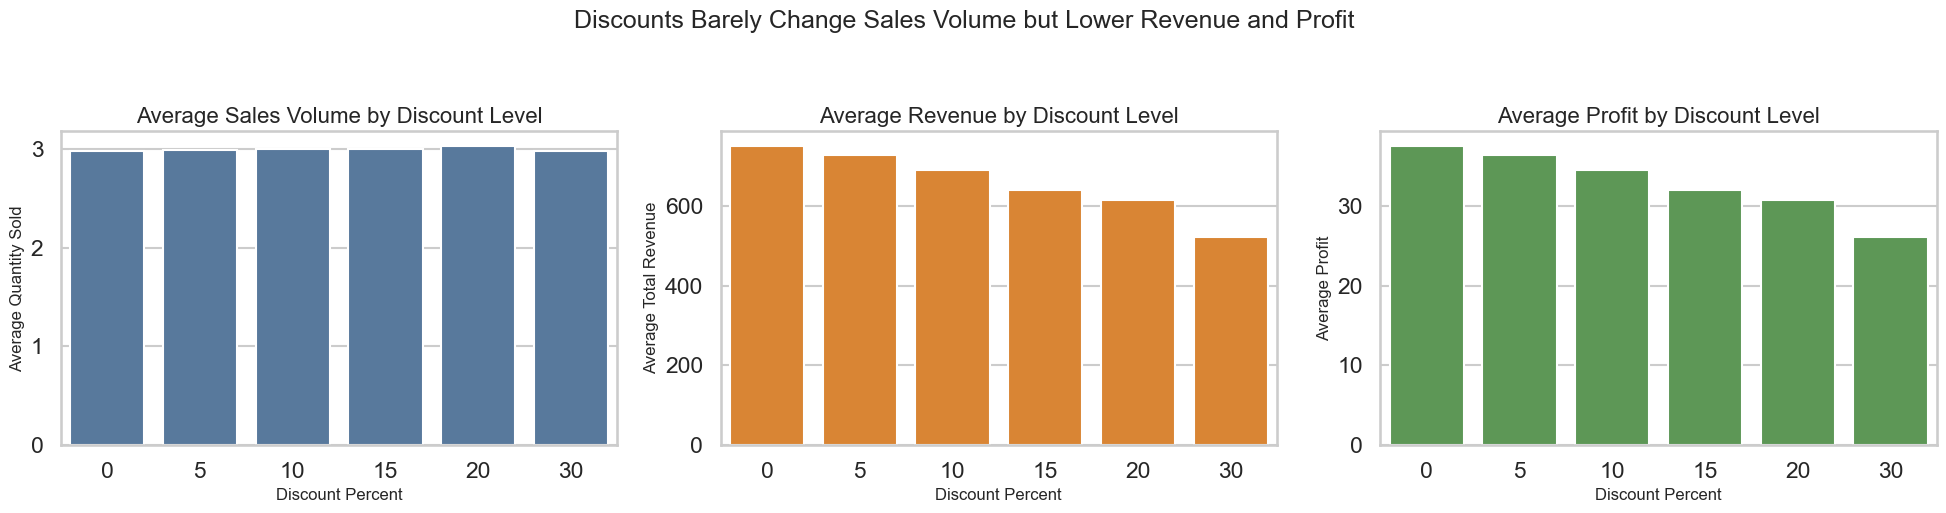

In [4]:
discount_summary = (
    df.groupby('discount_percent')
      .agg(
          orders=('order_id', 'count'),
          avg_quantity_sold=('quantity_sold', 'mean'),
          median_quantity_sold=('quantity_sold', 'median'),
          avg_total_revenue=('total_revenue', 'mean'),
          avg_profit=('profit', 'mean')
      )
      .reset_index()
)

display(discount_summary.round(3))

print('Correlation between discount and quantity_sold =', round(df['discount_percent'].corr(df['quantity_sold']), 4))
print('Correlation between discount and total_revenue =', round(df['discount_percent'].corr(df['total_revenue']), 4))
print('Correlation between discount and profit =', round(df['discount_percent'].corr(df['profit']), 4))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(data=discount_summary, x='discount_percent', y='avg_quantity_sold', ax=axes[0], color='#4C78A8')
sns.barplot(data=discount_summary, x='discount_percent', y='avg_total_revenue', ax=axes[1], color='#F58518')
sns.barplot(data=discount_summary, x='discount_percent', y='avg_profit', ax=axes[2], color='#54A24B')

axes[0].set_title('Average Sales Volume by Discount Level')
axes[0].set_xlabel('Discount Percent')
axes[0].set_ylabel('Average Quantity Sold')

axes[1].set_title('Average Revenue by Discount Level')
axes[1].set_xlabel('Discount Percent')
axes[1].set_ylabel('Average Total Revenue')

axes[2].set_title('Average Profit by Discount Level')
axes[2].set_xlabel('Discount Percent')
axes[2].set_ylabel('Average Profit')

plt.suptitle('Discounts Barely Change Sales Volume but Lower Revenue and Profit', y=1.04, fontsize=18)
plt.tight_layout()
plt.show()


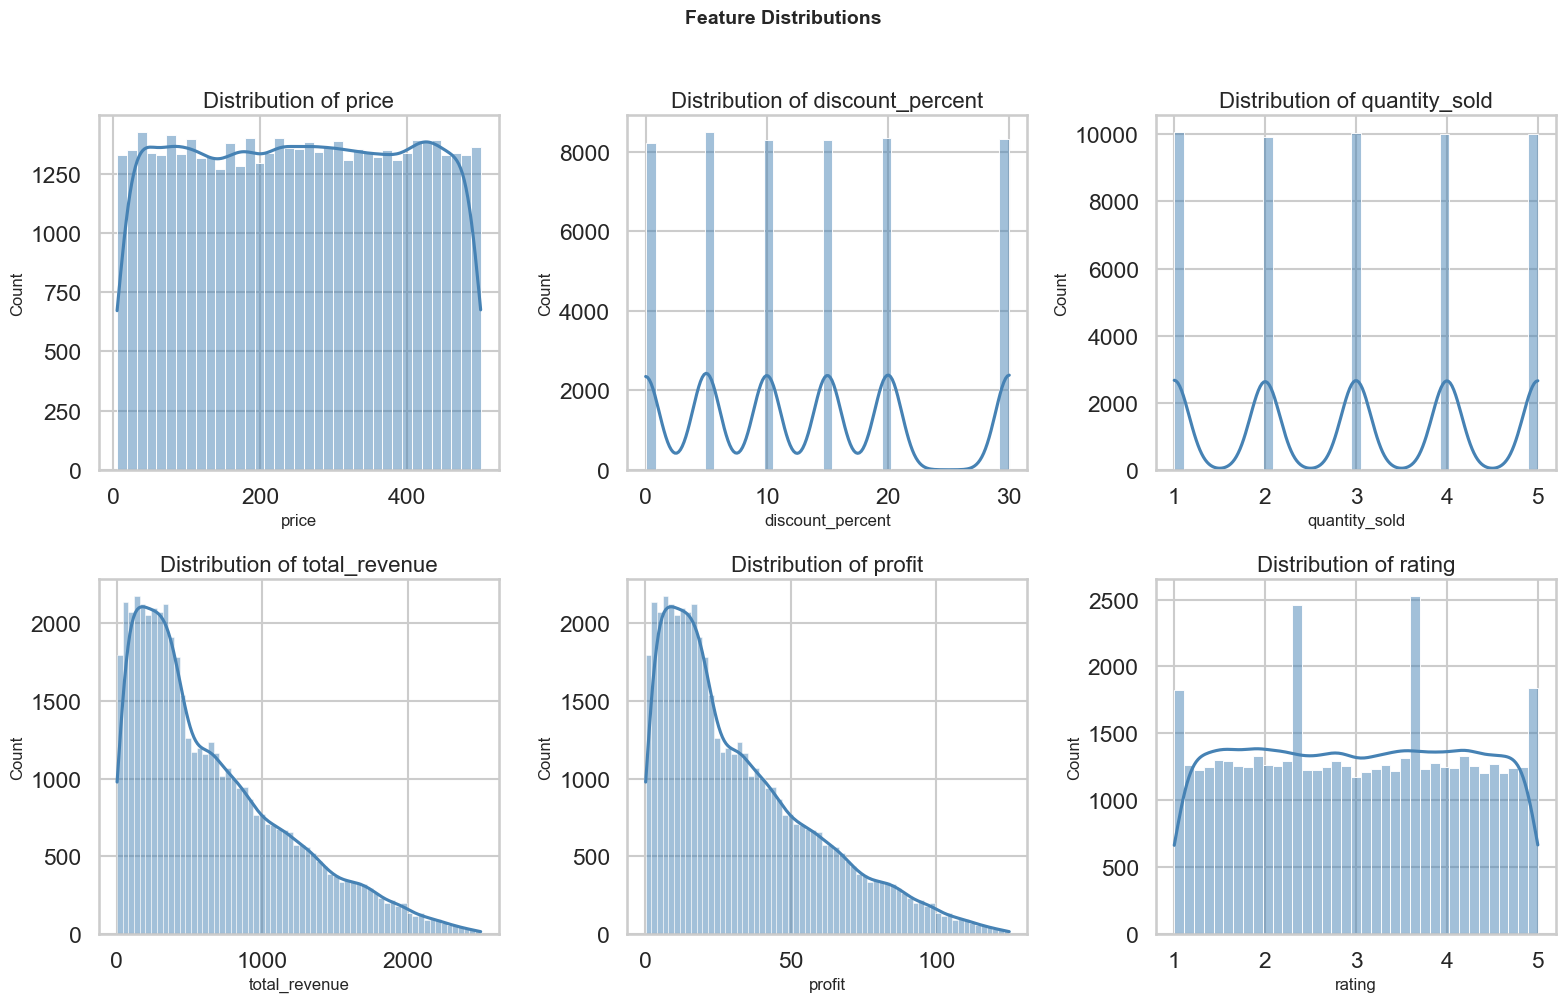

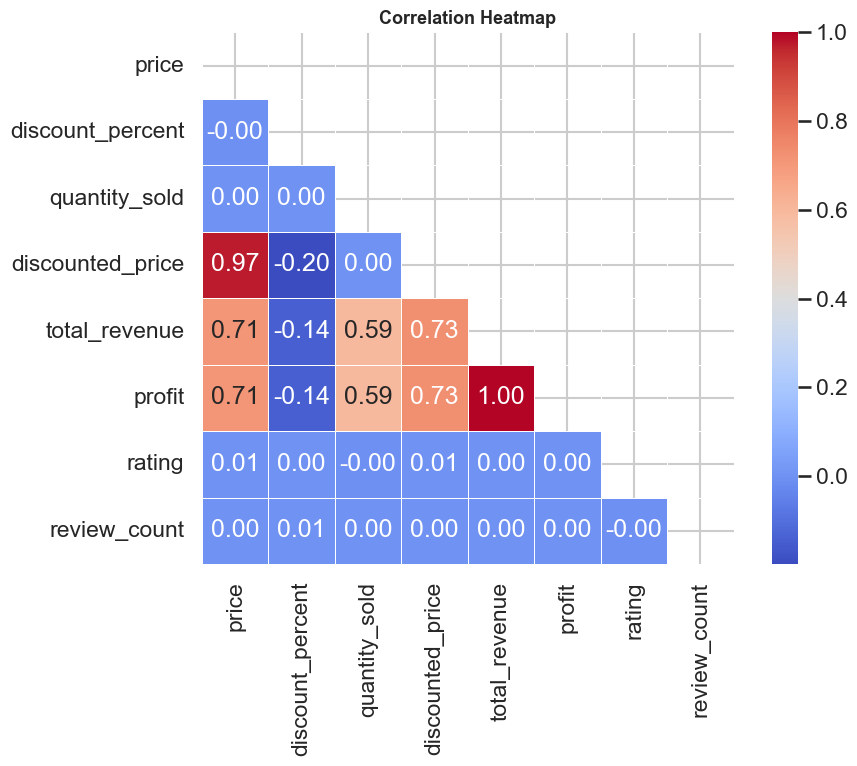

In [ ]:
# ──  Distribution plots 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
cols = ["price", "discount_percent", "quantity_sold",
        "total_revenue", "profit", "rating"]
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
plt.suptitle("Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig01_distributions.png", bbox_inches="tight")
plt.show()

# ──  Correlation heatmap 
num_cols = ["price", "discount_percent", "quantity_sold",
            "discounted_price", "total_revenue", "profit",
            "rating", "review_count"]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, square=True, linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig02_correlation.png", bbox_inches="tight")
plt.show()

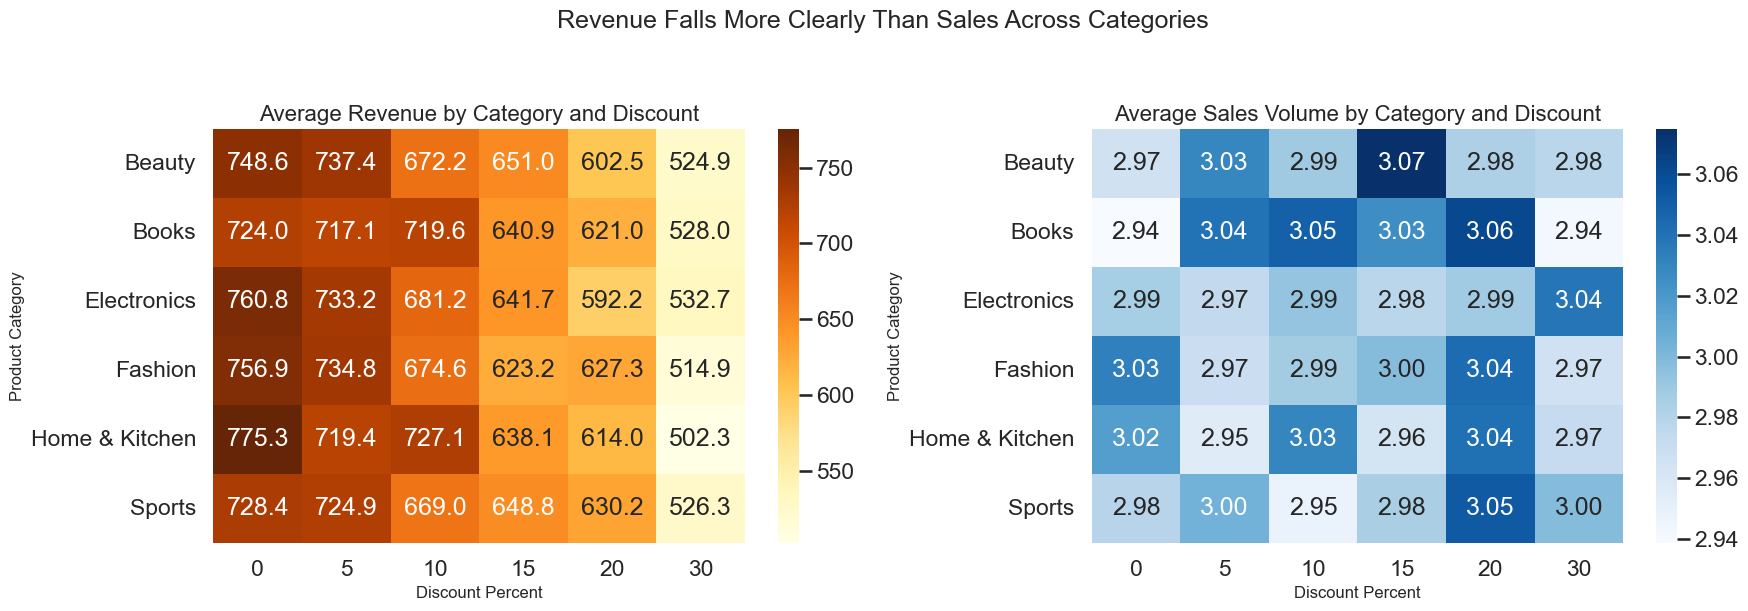

In [6]:
category_discount_revenue = df.pivot_table(
    index='product_category',
    columns='discount_percent',
    values='total_revenue',
    aggfunc='mean'
)

category_discount_sales = df.pivot_table(
    index='product_category',
    columns='discount_percent',
    values='quantity_sold',
    aggfunc='mean'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(category_discount_revenue, annot=True, fmt='.1f', cmap='YlOrBr', ax=axes[0])
sns.heatmap(category_discount_sales, annot=True, fmt='.2f', cmap='Blues', ax=axes[1])

axes[0].set_title('Average Revenue by Category and Discount')
axes[0].set_xlabel('Discount Percent')
axes[0].set_ylabel('Product Category')

axes[1].set_title('Average Sales Volume by Category and Discount')
axes[1].set_xlabel('Discount Percent')
axes[1].set_ylabel('Product Category')

plt.suptitle('Revenue Falls More Clearly Than Sales Across Categories', y=1.03, fontsize=18)
plt.tight_layout()
plt.show()


# Task 2: Regional and Category Patterns



,,total_revenue,total_sales
customer_region,product_category,,
Middle East,Books,"1,428,560.07",6517
Europe,Electronics,"1,407,118.94",6296
North America,Beauty,"1,402,769.67",6500
Asia,Beauty,"1,401,916.92",6317
North America,Home & Kitchen,"1,401,485.02",6350
Asia,Books,"1,391,961.69",6378
Middle East,Fashion,"1,390,228.60",6303
North America,Fashion,"1,389,302.51",6252
Middle East,Beauty,"1,387,711.96",6284


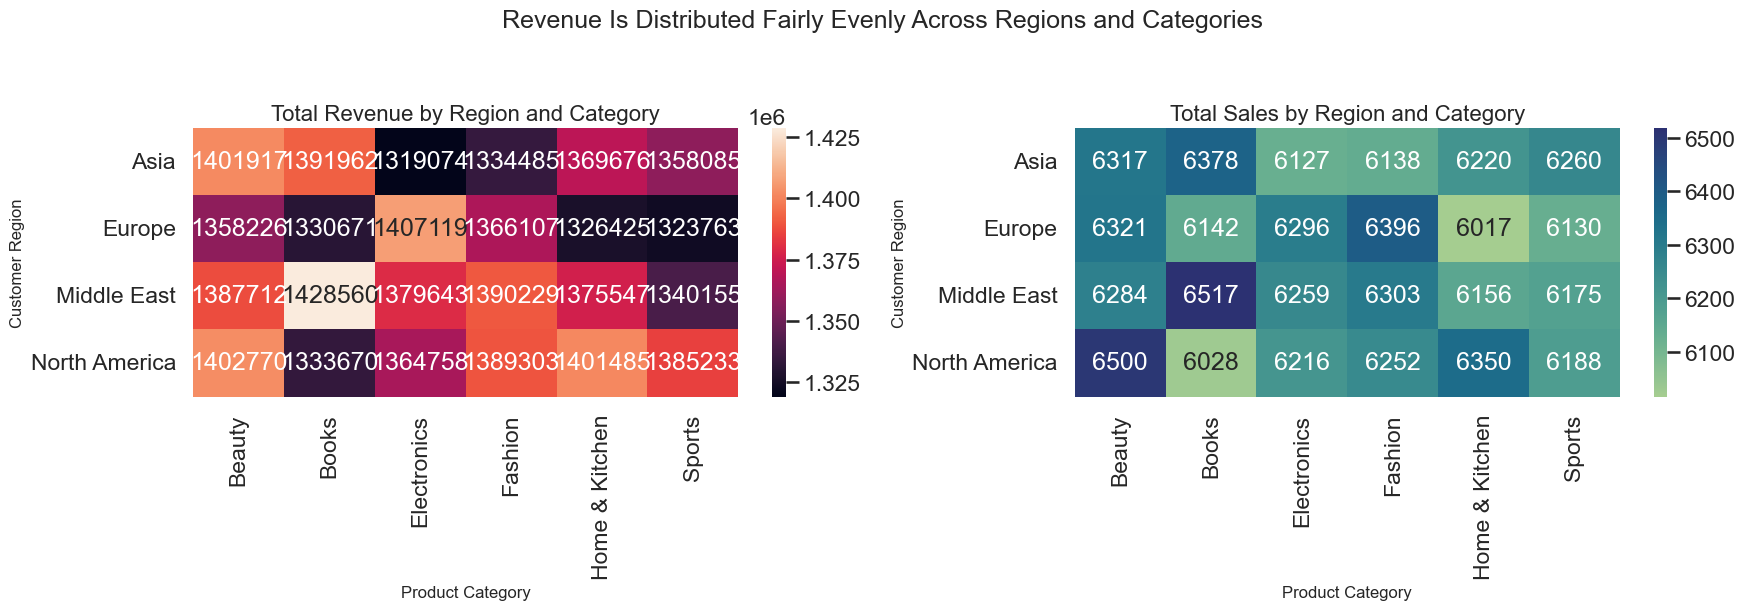

In [7]:
region_category_revenue = df.pivot_table(
    index='customer_region',
    columns='product_category',
    values='total_revenue',
    aggfunc='sum'
)

region_category_sales = df.pivot_table(
    index='customer_region',
    columns='product_category',
    values='quantity_sold',
    aggfunc='sum'
)

top_region_category = (
    df.groupby(['customer_region', 'product_category'])
      .agg(total_revenue=('total_revenue', 'sum'), total_sales=('quantity_sold', 'sum'))
      .sort_values('total_revenue', ascending=False)
      .head(12)
)
display(top_region_category.round(2))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(region_category_revenue, annot=True, fmt='.0f', cmap='rocket', ax=axes[0])
sns.heatmap(region_category_sales, annot=True, fmt='.0f', cmap='crest', ax=axes[1])

axes[0].set_title('Total Revenue by Region and Category')
axes[0].set_xlabel('Product Category')
axes[0].set_ylabel('Customer Region')

axes[1].set_title('Total Sales by Region and Category')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Customer Region')

plt.suptitle('Revenue Is Distributed Fairly Evenly Across Regions and Categories', y=1.03, fontsize=18)
plt.tight_layout()
plt.show()


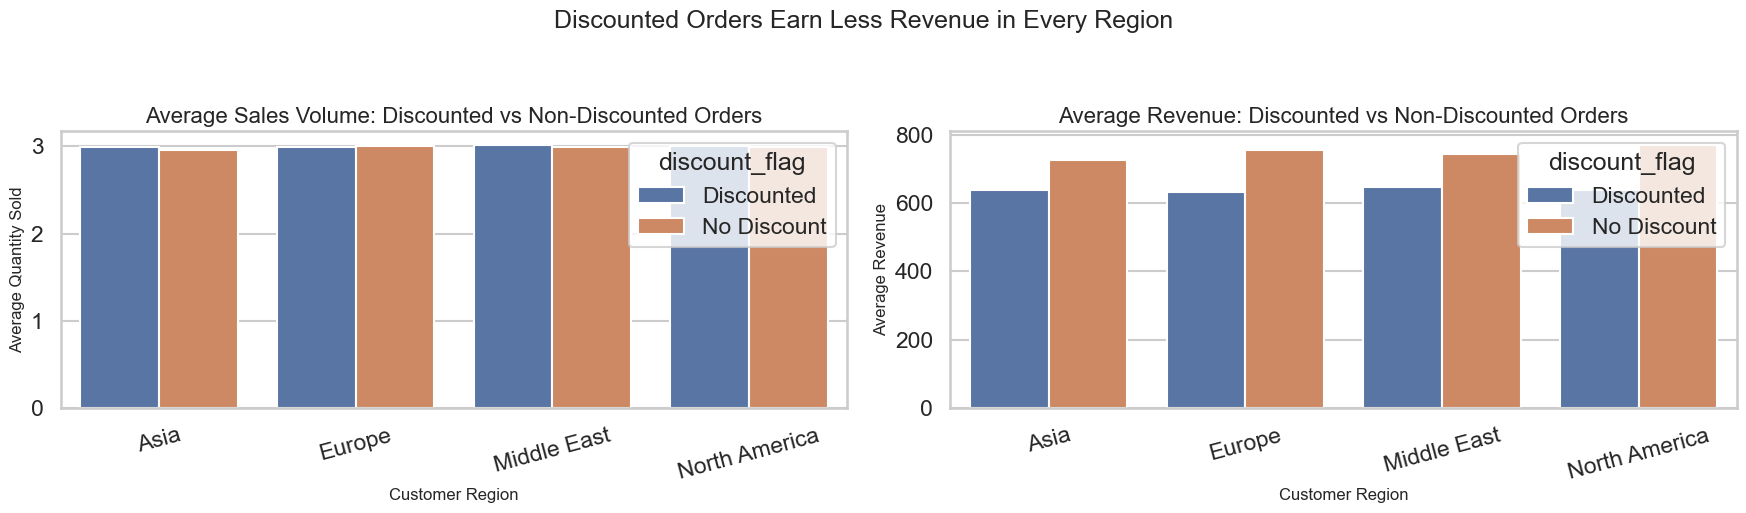

In [8]:
region_discount_effect = (
    df.groupby(['customer_region', 'discount_flag'])
      .agg(
          avg_sales=('quantity_sold', 'mean'),
          avg_revenue=('total_revenue', 'mean')
      )
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.barplot(data=region_discount_effect, x='customer_region', y='avg_sales', hue='discount_flag', ax=axes[0])
sns.barplot(data=region_discount_effect, x='customer_region', y='avg_revenue', hue='discount_flag', ax=axes[1])

axes[0].set_title('Average Sales Volume: Discounted vs Non-Discounted Orders')
axes[0].set_xlabel('Customer Region')
axes[0].set_ylabel('Average Quantity Sold')

axes[1].set_title('Average Revenue: Discounted vs Non-Discounted Orders')
axes[1].set_xlabel('Customer Region')
axes[1].set_ylabel('Average Revenue')

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Discounted Orders Earn Less Revenue in Every Region', y=1.04, fontsize=18)
plt.tight_layout()
plt.show()


# Task 3: Cluster Regions Based on Revenue Patterns


,k,K-Means,GMM,Hierarchical
0,2,0.34,0.31,0.31
1,3,0.26,0.14,0.23
2,4,0.24,0.19,0.21


Selected number of clusters for region-month analysis: 2


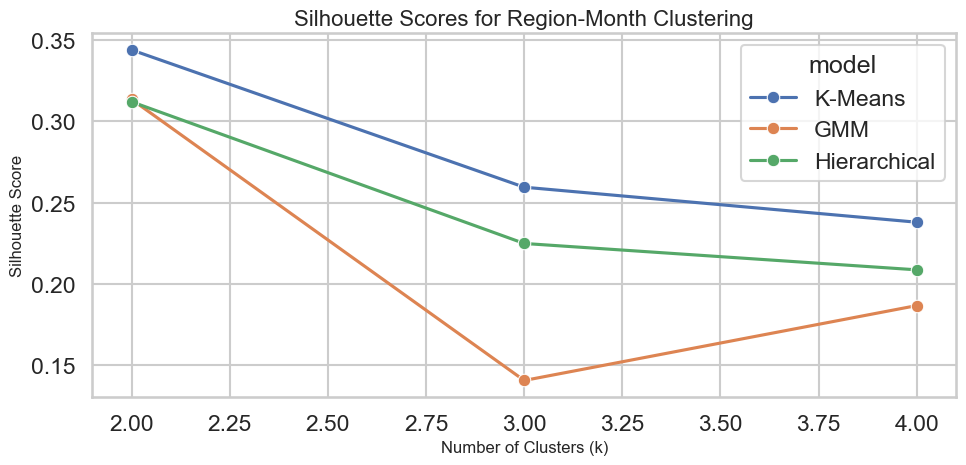

In [9]:
region_month = (
    df.groupby(['customer_region', 'month'])
      .agg(
          total_sales=('quantity_sold', 'sum'),
          total_revenue=('total_revenue', 'sum'),
          total_profit=('profit', 'sum'),
          avg_discount=('discount_percent', 'mean'),
          avg_price=('price', 'mean')
      )
      .reset_index()
)

region_feature_cols = ['total_sales', 'total_revenue', 'total_profit', 'avg_discount', 'avg_price']
X_region = StandardScaler().fit_transform(region_month[region_feature_cols])

cluster_diagnostics = []
for k in range(2, 5):
    km_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_region)
    gmm_labels = GaussianMixture(n_components=k, random_state=42).fit_predict(X_region)
    hier_labels = AgglomerativeClustering(n_clusters=k).fit_predict(X_region)
    cluster_diagnostics.append({
        'k': k,
        'K-Means': silhouette_score(X_region, km_labels),
        'GMM': silhouette_score(X_region, gmm_labels),
        'Hierarchical': silhouette_score(X_region, hier_labels)
    })

cluster_diagnostics = pd.DataFrame(cluster_diagnostics)
display(cluster_diagnostics.round(3))

best_region_k = int(cluster_diagnostics.sort_values('K-Means', ascending=False).iloc[0]['k'])
print('Selected number of clusters for region-month analysis:', best_region_k)

diagnostics_long = cluster_diagnostics.melt(id_vars='k', var_name='model', value_name='silhouette')
plt.figure(figsize=(10, 5))
sns.lineplot(data=diagnostics_long, x='k', y='silhouette', hue='model', marker='o')
plt.title('Silhouette Scores for Region-Month Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()


,total_sales,total_revenue,total_profit,avg_discount,avg_price
kmeans_cluster,,,,,
0,"1,628.17","358,753.39","17,937.67",13.32,253.60
1,"1,480.86","322,154.52","16,107.73",13.36,251.17


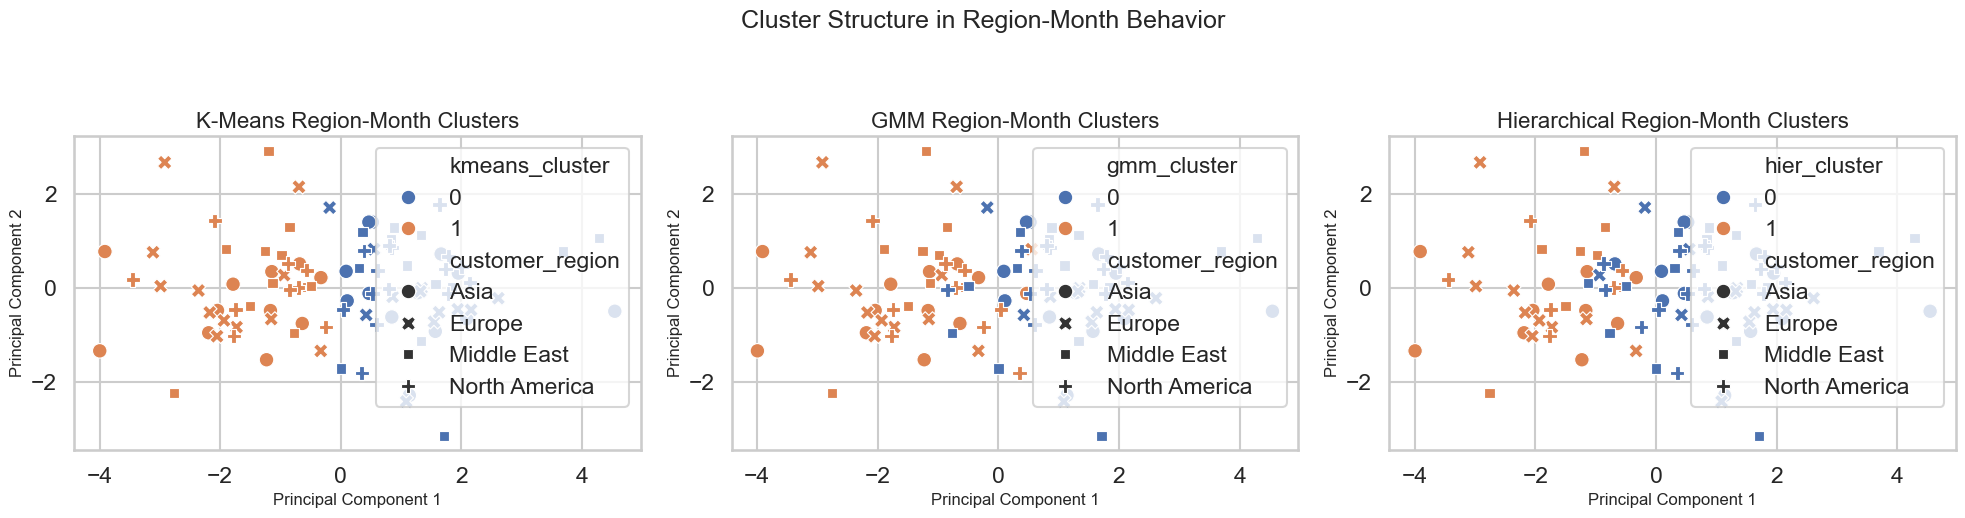

In [10]:
region_month['kmeans_cluster'] = KMeans(n_clusters=best_region_k, random_state=42, n_init=10).fit_predict(X_region)
region_month['gmm_cluster'] = GaussianMixture(n_components=best_region_k, random_state=42).fit_predict(X_region)
region_month['hier_cluster'] = AgglomerativeClustering(n_clusters=best_region_k).fit_predict(X_region)

region_profile = region_month.groupby('kmeans_cluster')[region_feature_cols].mean().round(2)
display(region_profile)

region_pca = PCA(n_components=2, random_state=42).fit_transform(X_region)
region_plot = region_month.copy()
region_plot['pc1'] = region_pca[:, 0]
region_plot['pc2'] = region_pca[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
cluster_views = [
    ('kmeans_cluster', 'K-Means Region-Month Clusters'),
    ('gmm_cluster', 'GMM Region-Month Clusters'),
    ('hier_cluster', 'Hierarchical Region-Month Clusters')
]

for ax, (cluster_col, title) in zip(axes, cluster_views):
    sns.scatterplot(
        data=region_plot,
        x='pc1',
        y='pc2',
        hue=cluster_col,
        style='customer_region',
        s=110,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')

plt.suptitle('Cluster Structure in Region-Month Behavior', y=1.05, fontsize=18)
plt.tight_layout()
plt.show()


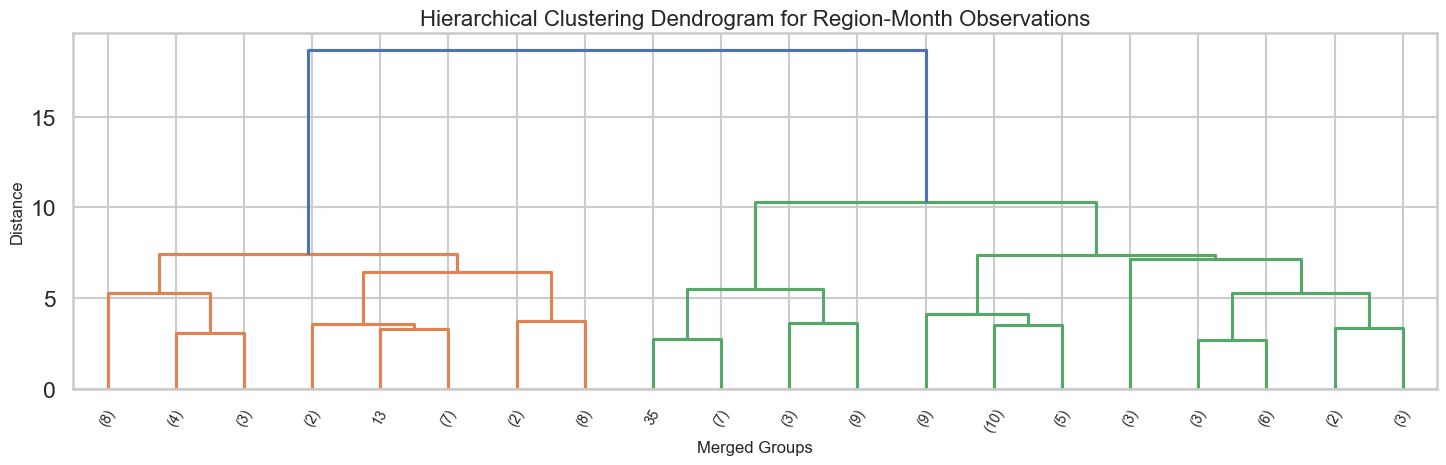

In [11]:
linked = linkage(X_region, method='ward')
plt.figure(figsize=(15, 5))
dendrogram(linked, truncate_mode='lastp', p=20, leaf_rotation=60, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram for Region-Month Observations')
plt.xlabel('Merged Groups')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


# Task 4: Group Products Based on Sales and Profit Patterns


,k,silhouette
0,2,0.26
1,3,0.17
2,4,0.17
3,5,0.16
4,6,0.17


Selected number of product clusters: 2


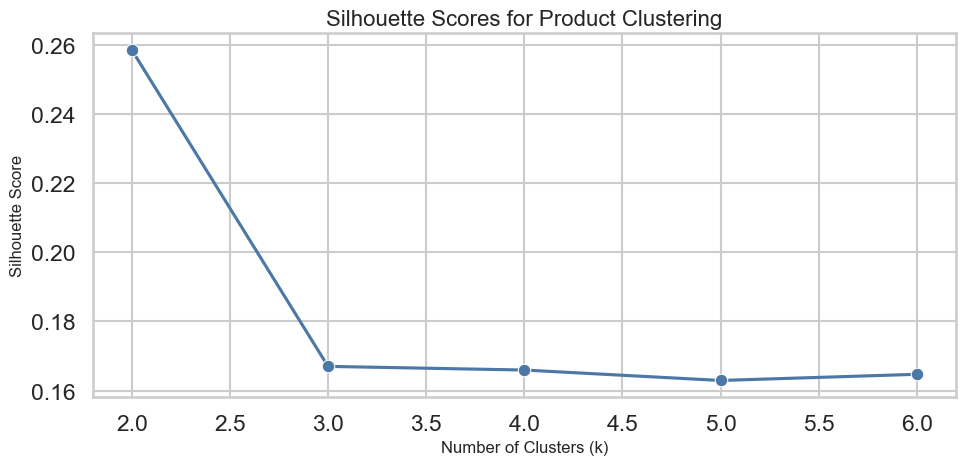

In [12]:
product_features = (
    df.groupby('product_id')
      .agg(
          total_sales=('quantity_sold', 'sum'),
          total_revenue=('total_revenue', 'sum'),
          total_profit=('profit', 'sum'),
          avg_discount=('discount_percent', 'mean'),
          avg_rating=('rating', 'mean'),
          avg_reviews=('review_count', 'mean')
      )
      .reset_index()
)

product_category_map = (
    df.groupby('product_id')['product_category']
      .agg(lambda values: values.mode().iat[0])
      .rename('product_category')
      .reset_index()
)

product_features = product_features.merge(product_category_map, on='product_id', how='left')

product_feature_cols = ['total_sales', 'total_revenue', 'total_profit', 'avg_discount', 'avg_rating', 'avg_reviews']
X_product = StandardScaler().fit_transform(product_features[product_feature_cols])

product_scores = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_product)
    product_scores.append({'k': k, 'silhouette': silhouette_score(X_product, labels)})

product_scores = pd.DataFrame(product_scores)
display(product_scores.round(3))

best_product_k = int(product_scores.sort_values('silhouette', ascending=False).iloc[0]['k'])
print('Selected number of product clusters:', best_product_k)

plt.figure(figsize=(10, 5))
sns.lineplot(data=product_scores, x='k', y='silhouette', marker='o', color='#4C78A8')
plt.title('Silhouette Scores for Product Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()


,total_sales,total_revenue,total_profit,avg_discount,avg_rating,avg_reviews
cluster,,,,,,
0,29.85,"6,146.94",307.35,13.46,3.00,249.92
1,47.40,"10,902.14",545.11,13.13,3.00,248.72


product_category,Beauty,Books,Electronics,Fashion,Home & Kitchen,Sports
cluster,,,,,,
0,592,470,385,304,261,247
1,404,342,291,273,233,198


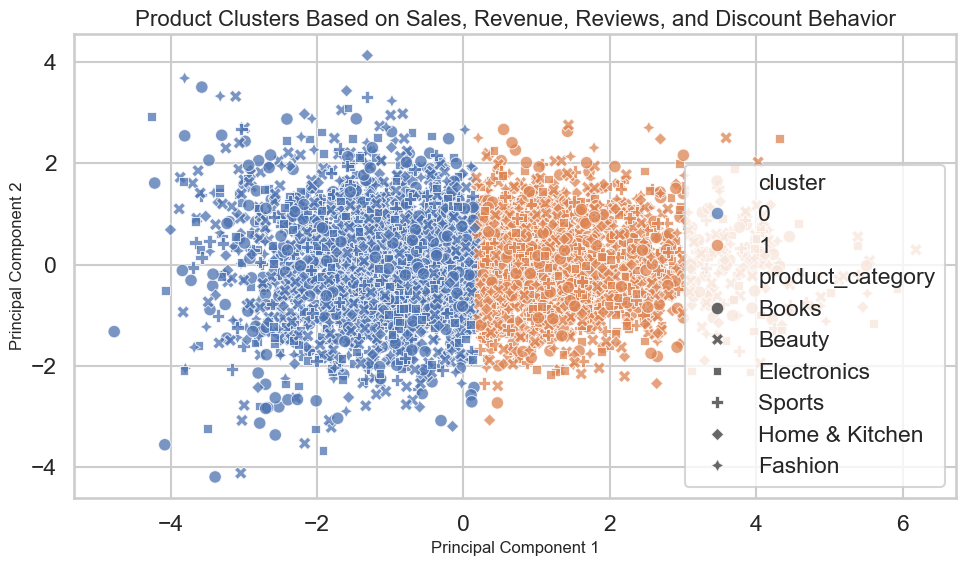

In [13]:
product_features['cluster'] = KMeans(n_clusters=best_product_k, random_state=42, n_init=10).fit_predict(X_product)

product_profile = product_features.groupby('cluster')[product_feature_cols].mean().round(2)
display(product_profile)
display(pd.crosstab(product_features['cluster'], product_features['product_category']))

product_pca = PCA(n_components=2, random_state=42).fit_transform(X_product)
product_features['pc1'] = product_pca[:, 0]
product_features['pc2'] = product_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=product_features,
    x='pc1',
    y='pc2',
    hue='cluster',
    style='product_category',
    alpha=0.75,
    s=80
)
plt.title('Product Clusters Based on Sales, Revenue, Reviews, and Discount Behavior')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()


# Task 5: Time Series Analysis


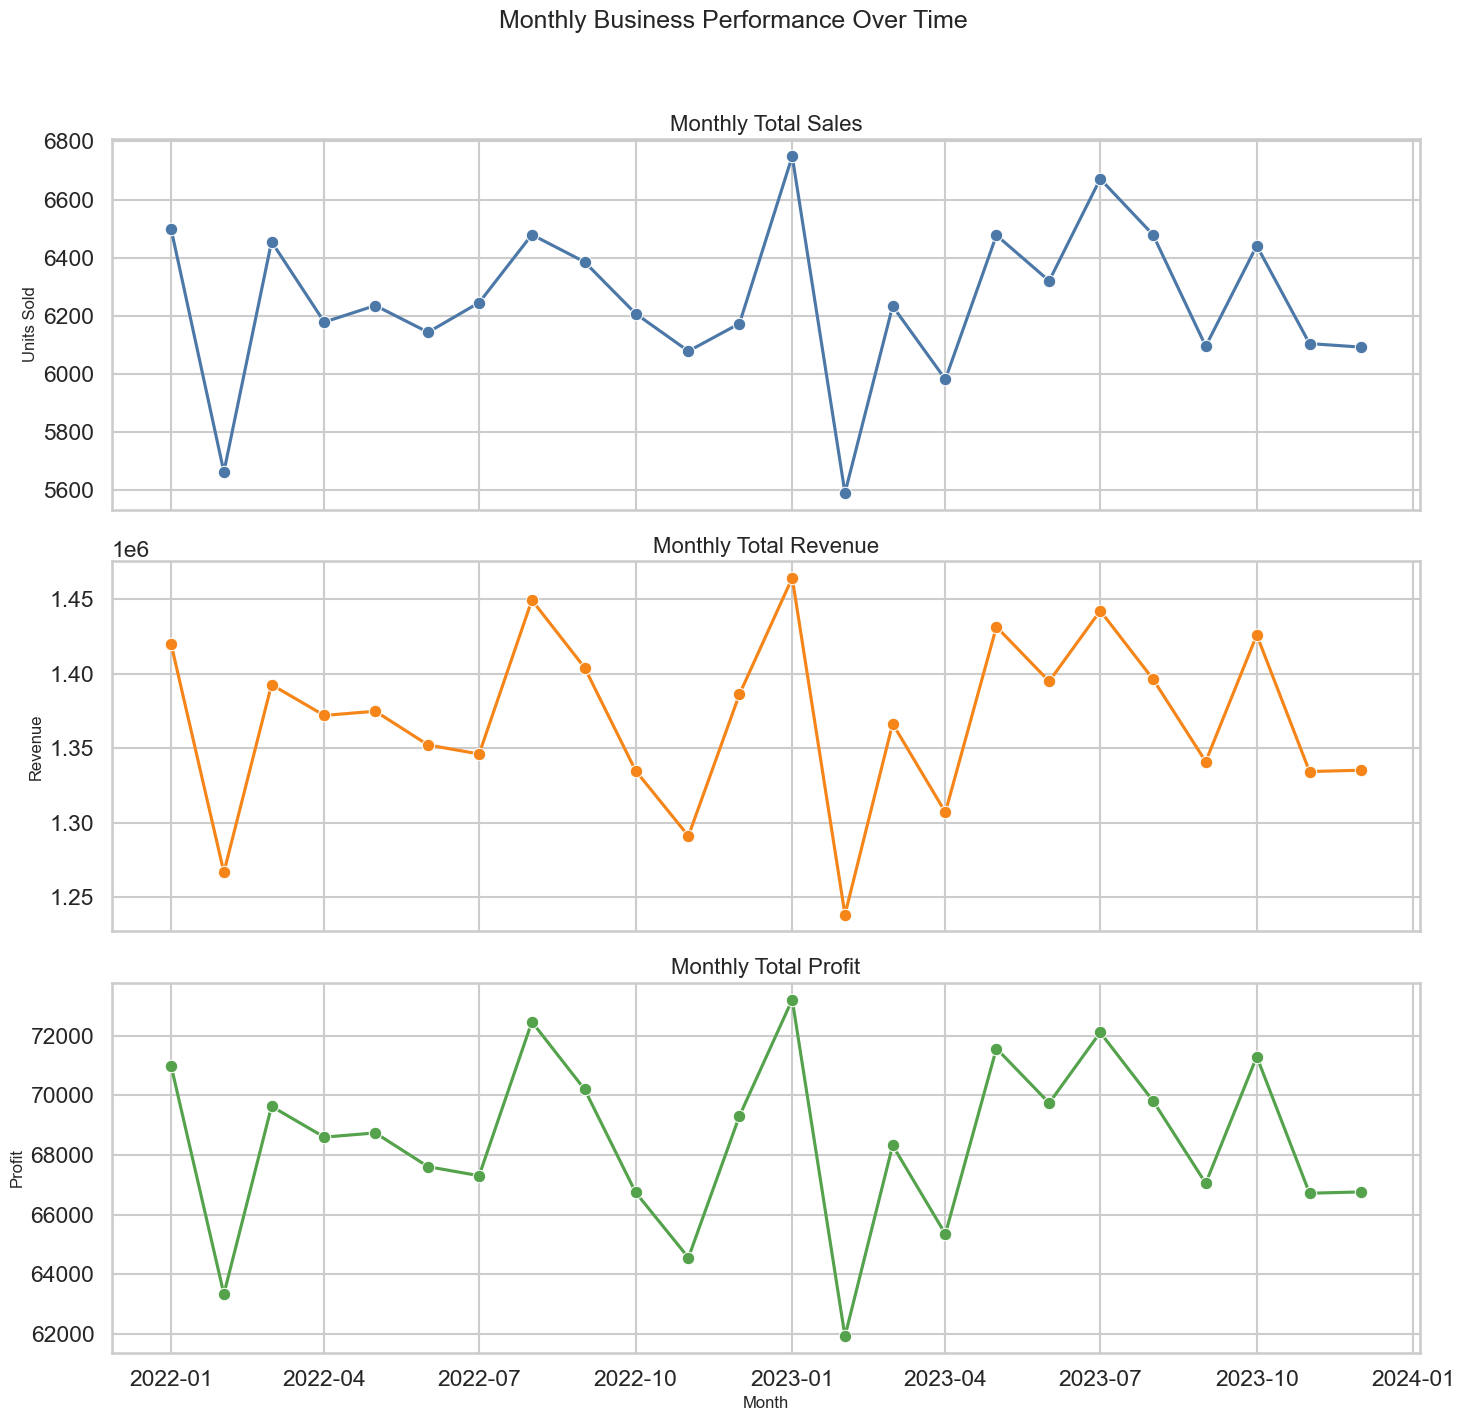

In [14]:
monthly = (
    df.groupby('month')
      .agg(
          total_sales=('quantity_sold', 'sum'),
          total_revenue=('total_revenue', 'sum'),
          total_profit=('profit', 'sum')
      )
      .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)
sns.lineplot(data=monthly, x='month', y='total_sales', marker='o', ax=axes[0], color='#4C78A8')
sns.lineplot(data=monthly, x='month', y='total_revenue', marker='o', ax=axes[1], color='#F58518')
sns.lineplot(data=monthly, x='month', y='total_profit', marker='o', ax=axes[2], color='#54A24B')

axes[0].set_title('Monthly Total Sales')
axes[0].set_ylabel('Units Sold')

axes[1].set_title('Monthly Total Revenue')
axes[1].set_ylabel('Revenue')

axes[2].set_title('Monthly Total Profit')
axes[2].set_ylabel('Profit')
axes[2].set_xlabel('Month')

plt.suptitle('Monthly Business Performance Over Time', y=1.02, fontsize=18)
plt.tight_layout()
plt.show()


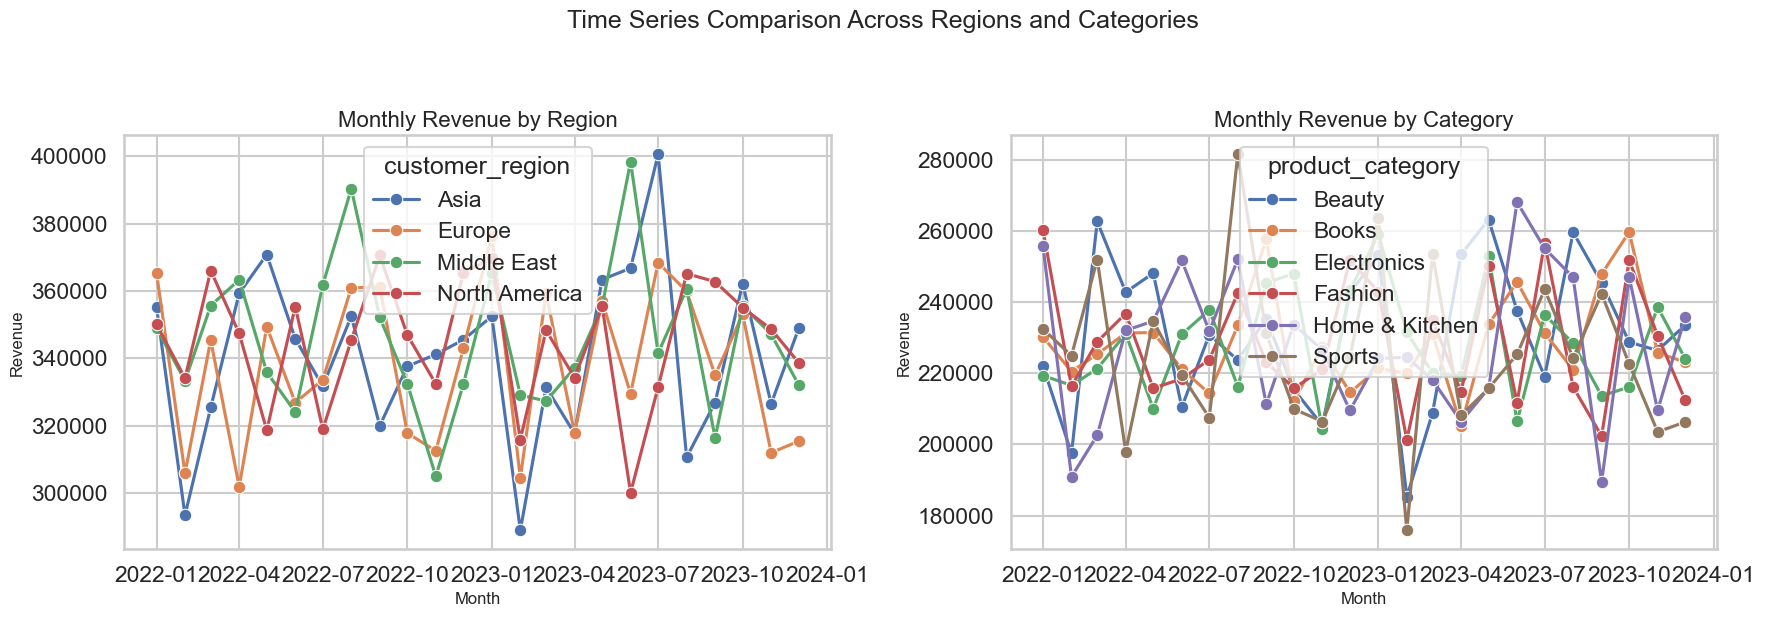

In [15]:
monthly_by_region = (
    df.groupby(['month', 'customer_region'])
      .agg(total_revenue=('total_revenue', 'sum'), total_sales=('quantity_sold', 'sum'))
      .reset_index()
)

monthly_by_category = (
    df.groupby(['month', 'product_category'])
      .agg(total_revenue=('total_revenue', 'sum'), total_sales=('quantity_sold', 'sum'))
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.lineplot(data=monthly_by_region, x='month', y='total_revenue', hue='customer_region', marker='o', ax=axes[0])
sns.lineplot(data=monthly_by_category, x='month', y='total_revenue', hue='product_category', marker='o', ax=axes[1])

axes[0].set_title('Monthly Revenue by Region')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue')

axes[1].set_title('Monthly Revenue by Category')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue')

plt.suptitle('Time Series Comparison Across Regions and Categories', y=1.04, fontsize=18)
plt.tight_layout()
plt.show()


# Task 6: Regression Analysis


In [16]:
model_builders = {
    'Linear Regression': lambda: LinearRegression(),
    'Ridge': lambda: Ridge(alpha=0.001),
    'Lasso': lambda: Lasso(alpha=0.001, max_iter=10000)
}

def evaluate_models(data, target, numeric_cols, categorical_cols):
    X = data[numeric_cols + categorical_cols]
    y = data[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
        ]
    )

    results = []
    fitted_models = {}
    for name, build_estimator in model_builders.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', build_estimator())
        ])
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)
        results.append({
            'model': name,
            'MAE': mean_absolute_error(y_test, predictions),
            'RMSE': np.sqrt(mean_squared_error(y_test, predictions)),
            'R2': r2_score(y_test, predictions)
        })
        fitted_models[name] = pipeline

    return pd.DataFrame(results).sort_values('R2', ascending=False), fitted_models, X_test, y_test

def get_coefficients(pipeline):
    feature_names = list(pipeline.named_steps['preprocessor'].get_feature_names_out())
    coefs = np.asarray(pipeline.named_steps['model'].coef_).ravel()

    if len(coefs) != len(feature_names):
        raise ValueError(
            'Coefficient length mismatch detected. This usually happens when the kernel is still holding '            'an older fitted model from a previous notebook version. Please restart the kernel and run the '            'notebook from the top so the models and feature names are recreated together.'
        )

    return pd.Series(coefs, index=feature_names).sort_values(key=lambda s: np.abs(s), ascending=False)

sales_numeric = ['discount_percent', 'price', 'rating', 'review_count']
sales_categorical = ['product_category', 'customer_region']

revenue_numeric = ['discount_percent', 'price', 'quantity_sold']
revenue_categorical = ['product_category', 'customer_region']

sales_results, sales_models, X_test_sales, y_test_sales = evaluate_models(
    df,
    target='quantity_sold',
    numeric_cols=sales_numeric,
    categorical_cols=sales_categorical
)

revenue_results, revenue_models, X_test_revenue, y_test_revenue = evaluate_models(
    df,
    target='total_revenue',
    numeric_cols=revenue_numeric,
    categorical_cols=revenue_categorical
)

display(sales_results.round(4))
display(revenue_results.round(4))

sales_coefficients = get_coefficients(sales_models['Linear Regression'])
revenue_coefficients = get_coefficients(revenue_models['Linear Regression'])

display(sales_coefficients.head(12).rename('sales_coefficient').to_frame())
display(revenue_coefficients.head(12).rename('revenue_coefficient').to_frame())

print('Sales model discount coefficient:', round(sales_coefficients.loc['num__discount_percent'], 4))
print('Revenue model discount coefficient:', round(revenue_coefficients.loc['num__discount_percent'], 4))


,model,MAE,RMSE,R2
2,Lasso,1.20,1.41,-0.00
1,Ridge,1.20,1.41,-0.00
0,Linear Regression,1.20,1.41,-0.00


,model,MAE,RMSE,R2
2,Lasso,139.41,187.22,0.87
1,Ridge,139.41,187.22,0.87
0,Linear Regression,139.41,187.22,0.87


,sales_coefficient
cat__customer_region_Middle East,0.02
cat__customer_region_North America,0.02
cat__product_category_Books,0.01
cat__product_category_Electronics,-0.01
cat__product_category_Fashion,-0.01
cat__product_category_Sports,-0.01
num__rating,-0.01
cat__customer_region_Europe,0.01
num__review_count,-0.01
cat__product_category_Home & Kitchen,-0.00


,revenue_coefficient
num__price,373.82
num__quantity_sold,312.47
num__discount_percent,-75.00
cat__product_category_Home & Kitchen,5.36
cat__product_category_Electronics,4.55
cat__customer_region_North America,3.38
cat__customer_region_Europe,-1.39
cat__product_category_Sports,1.16
cat__customer_region_Middle East,0.77
cat__product_category_Fashion,0.73


Sales model discount coefficient: 0.0045
Revenue model discount coefficient: -74.9962


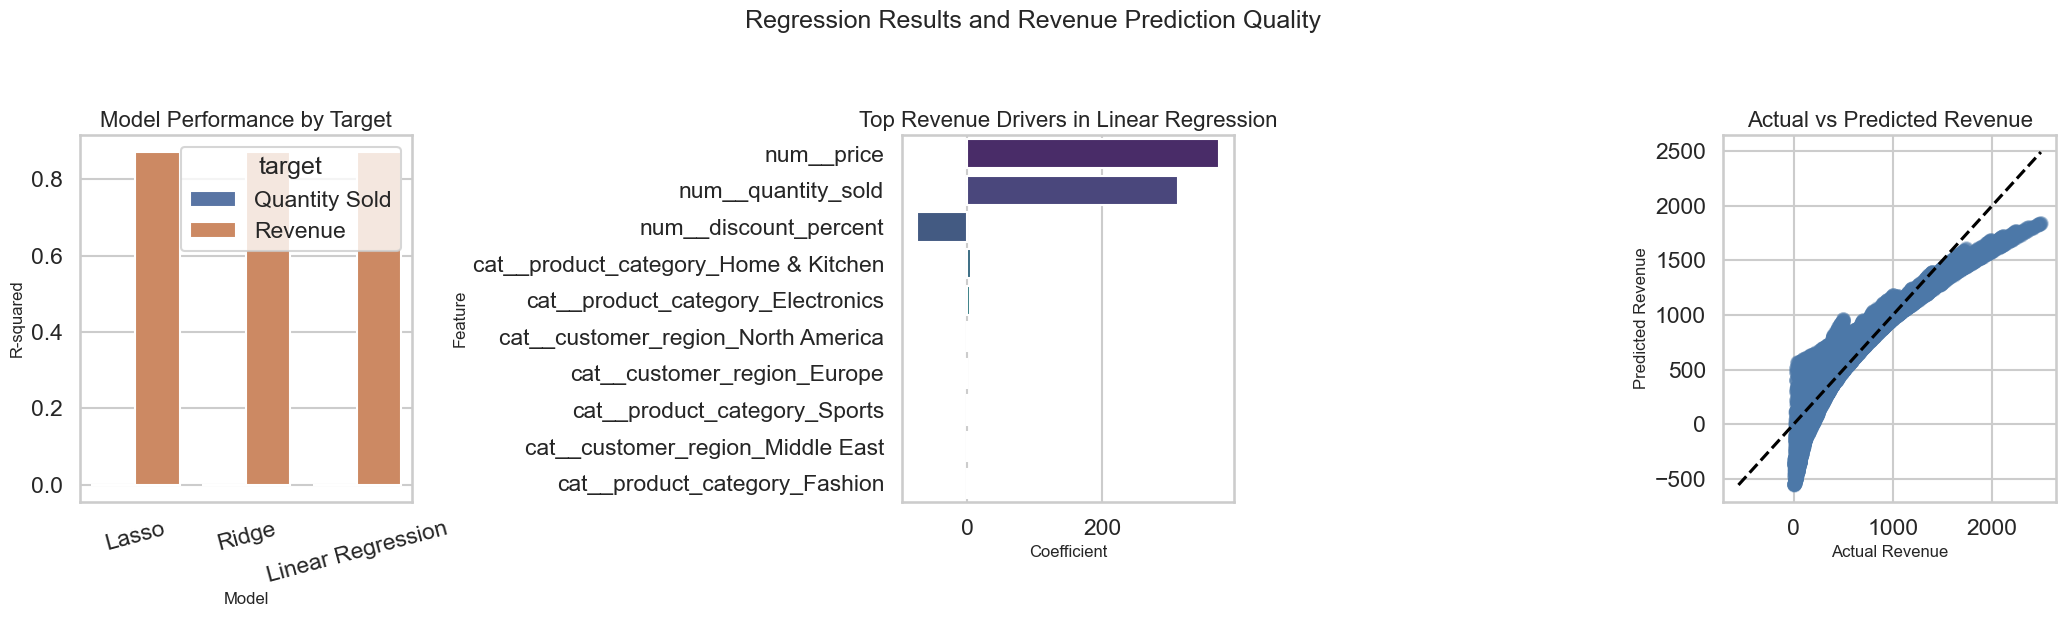

In [17]:
sales_plot = sales_results.copy()
sales_plot['target'] = 'Quantity Sold'
revenue_plot = revenue_results.copy()
revenue_plot['target'] = 'Revenue'
model_plot = pd.concat([sales_plot, revenue_plot], ignore_index=True)

top_revenue_coefs = revenue_coefficients.head(10).reset_index()
top_revenue_coefs.columns = ['feature', 'coefficient']

predicted_revenue = revenue_models['Linear Regression'].predict(X_test_revenue)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
sns.barplot(data=model_plot, x='model', y='R2', hue='target', ax=axes[0])
axes[0].set_title('Model Performance by Target')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R-squared')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=top_revenue_coefs, x='coefficient', y='feature', ax=axes[1], palette='viridis')
axes[1].set_title('Top Revenue Drivers in Linear Regression')
axes[1].set_xlabel('Coefficient')
axes[1].set_ylabel('Feature')

axes[2].scatter(y_test_revenue, predicted_revenue, alpha=0.35, color='#4C78A8')
min_val = min(y_test_revenue.min(), predicted_revenue.min())
max_val = max(y_test_revenue.max(), predicted_revenue.max())
axes[2].plot([min_val, max_val], [min_val, max_val], linestyle='--', color='black')
axes[2].set_title('Actual vs Predicted Revenue')
axes[2].set_xlabel('Actual Revenue')
axes[2].set_ylabel('Predicted Revenue')

plt.suptitle('Regression Results and Revenue Prediction Quality', y=1.04, fontsize=18)
plt.tight_layout()
plt.show()
